In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

x = np.load('/content/drive/MyDrive/alphabet/images_over.npy')
y = np.load('/content/drive/MyDrive/alphabet/encoded_labels_over.npy')

# لو الصور رمادية، نضيف قناة واحدة
if len(x.shape) == 3:
    x = np.expand_dims(x, axis=-1)

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

input_shape = x.shape[1:]
num_classes = len(np.unique(y))


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_cnn():
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        # --- Dense Layers ---
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Adam(1e-4),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model



--- Run 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 54s - 78ms/step - accuracy: 0.6930 - loss: 1.0603 - val_accuracy: 0.9632 - val_loss: 0.1562
Epoch 2/20
694/694 - 60s - 87ms/step - accuracy: 0.9692 - loss: 0.1074 - val_accuracy: 0.9772 - val_loss: 0.0739
Epoch 3/20
694/694 - 27s - 39ms/step - accuracy: 0.9852 - loss: 0.0525 - val_accuracy: 0.9915 - val_loss: 0.0349
Epoch 4/20
694/694 - 41s - 59ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9917 - val_loss: 0.0345
Epoch 5/20
694/694 - 40s - 58ms/step - accuracy: 0.9877 - loss: 0.0438 - val_accuracy: 0.9888 - val_loss: 0.0342
Epoch 6/20
694/694 - 41s - 59ms/step - accuracy: 0.9919 - loss: 0.0275 - val_accuracy: 0.9905 - val_loss: 0.0371
Epoch 7/20
694/694 - 27s - 38ms/step - accuracy: 0.9897 - loss: 0.0348 - val_accuracy: 0.9927 - val_loss: 0.0286
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9914 - loss: 0.0268 - val_accuracy: 0.9953 - val_loss: 0.0176
Epoch 9/20
694/694 - 42s - 60ms/step - accuracy: 0.9935 - loss: 0.0220 - val_accuracy: 0.9907 - 

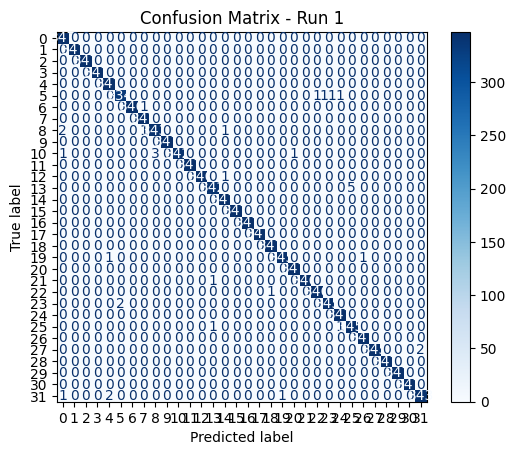

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9960 | ROC AUC: 1.0000
F1 Weighted: 0.9961 | Precision Weighted: 0.9962 | Recall Weighted: 0.9961
Training Time: 783.92s | Memory Used: 1088.90 MB

--- Run 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 42s - 61ms/step - accuracy: 0.7217 - loss: 0.9803 - val_accuracy: 0.9734 - val_loss: 0.1216
Epoch 2/20
694/694 - 28s - 40ms/step - accuracy: 0.9728 - loss: 0.0968 - val_accuracy: 0.9925 - val_loss: 0.0294
Epoch 3/20
694/694 - 40s - 58ms/step - accuracy: 0.9864 - loss: 0.0498 - val_accuracy: 0.9914 - val_loss: 0.0313
Epoch 4/20
694/694 - 40s - 58ms/step - accuracy: 0.9885 - loss: 0.0397 - val_accuracy: 0.9912 - val_loss: 0.0296
Epoch 5/20
694/694 - 41s - 59ms/step - accuracy: 0.9881 - loss: 0.0409 - val_accuracy: 0.9923 - val_loss: 0.0284
Epoch 6/20
694/694 - 41s - 59ms/step - accuracy: 0.9911 - loss: 0.0295 - val_accuracy: 0.9939 - val_loss: 0.0241
Epoch 7/20
694/694 - 27s - 38ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9960 - val_loss: 0.0173
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9911 - loss: 0.0306 - val_accuracy: 0.9769 - val_loss: 0.1083
Epoch 9/20
694/694 - 41s - 60ms/step - accuracy: 0.9928 - loss: 0.0248 - val_accuracy: 0.9846 - 

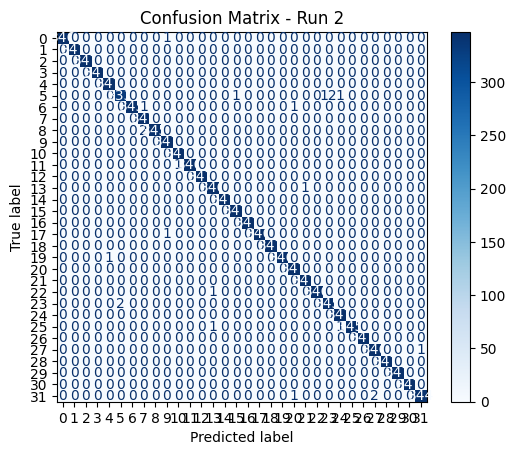

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9970 | ROC AUC: 0.9999
F1 Weighted: 0.9971 | Precision Weighted: 0.9971 | Recall Weighted: 0.9971
Training Time: 779.28s | Memory Used: 203.11 MB

--- Run 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 43s - 62ms/step - accuracy: 0.7104 - loss: 1.0070 - val_accuracy: 0.9747 - val_loss: 0.1152
Epoch 2/20
694/694 - 27s - 39ms/step - accuracy: 0.9718 - loss: 0.0997 - val_accuracy: 0.9857 - val_loss: 0.0503
Epoch 3/20
694/694 - 40s - 58ms/step - accuracy: 0.9843 - loss: 0.0548 - val_accuracy: 0.9910 - val_loss: 0.0347
Epoch 4/20
694/694 - 27s - 39ms/step - accuracy: 0.9885 - loss: 0.0403 - val_accuracy: 0.9918 - val_loss: 0.0332
Epoch 5/20
694/694 - 41s - 59ms/step - accuracy: 0.9883 - loss: 0.0383 - val_accuracy: 0.9908 - val_loss: 0.0337
Epoch 6/20
694/694 - 41s - 60ms/step - accuracy: 0.9893 - loss: 0.0337 - val_accuracy: 0.9923 - val_loss: 0.0306
Epoch 7/20
694/694 - 40s - 57ms/step - accuracy: 0.9916 - loss: 0.0295 - val_accuracy: 0.9949 - val_loss: 0.0231
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9915 - loss: 0.0272 - val_accuracy: 0.9884 - val_loss: 0.0385
Epoch 9/20
694/694 - 42s - 60ms/step - accuracy: 0.9923 - loss: 0.0274 - val_accuracy: 0.9905 - 

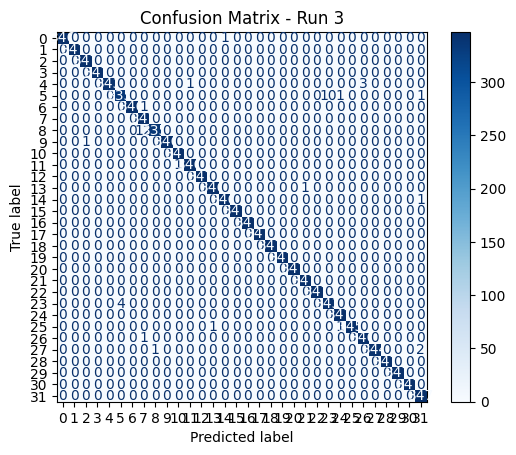

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9959 | ROC AUC: 1.0000
F1 Weighted: 0.9960 | Precision Weighted: 0.9961 | Recall Weighted: 0.9960
Training Time: 723.92s | Memory Used: 164.88 MB

--- Run 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 40s - 58ms/step - accuracy: 0.7015 - loss: 1.0269 - val_accuracy: 0.9609 - val_loss: 0.1703
Epoch 2/20
694/694 - 33s - 48ms/step - accuracy: 0.9721 - loss: 0.0988 - val_accuracy: 0.9874 - val_loss: 0.0478
Epoch 3/20
694/694 - 41s - 60ms/step - accuracy: 0.9855 - loss: 0.0509 - val_accuracy: 0.9941 - val_loss: 0.0246
Epoch 4/20
694/694 - 41s - 59ms/step - accuracy: 0.9883 - loss: 0.0394 - val_accuracy: 0.9897 - val_loss: 0.0380
Epoch 5/20
694/694 - 40s - 58ms/step - accuracy: 0.9897 - loss: 0.0372 - val_accuracy: 0.9925 - val_loss: 0.0308
Epoch 6/20
694/694 - 41s - 59ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.9926 - val_loss: 0.0270
Epoch 7/20
694/694 - 41s - 59ms/step - accuracy: 0.9921 - loss: 0.0258 - val_accuracy: 0.9859 - val_loss: 0.0471
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9909 - loss: 0.0300 - val_accuracy: 0.9889 - val_loss: 0.0393
Epoch 9/20
694/694 - 42s - 60ms/step - accuracy: 0.9946 - loss: 0.0183 - val_accuracy: 0.9884 - 

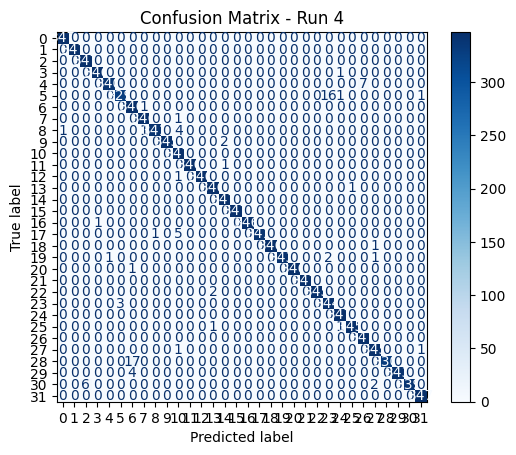

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9916 | ROC AUC: 0.9999
F1 Weighted: 0.9919 | Precision Weighted: 0.9921 | Recall Weighted: 0.9919
Training Time: 797.49s | Memory Used: 162.02 MB

--- Run 5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 41s - 58ms/step - accuracy: 0.6853 - loss: 1.0904 - val_accuracy: 0.9598 - val_loss: 0.1601
Epoch 2/20
694/694 - 33s - 47ms/step - accuracy: 0.9691 - loss: 0.1061 - val_accuracy: 0.9878 - val_loss: 0.0450
Epoch 3/20
694/694 - 41s - 59ms/step - accuracy: 0.9857 - loss: 0.0521 - val_accuracy: 0.9925 - val_loss: 0.0356
Epoch 4/20
694/694 - 27s - 38ms/step - accuracy: 0.9882 - loss: 0.0398 - val_accuracy: 0.9885 - val_loss: 0.0409
Epoch 5/20
694/694 - 26s - 38ms/step - accuracy: 0.9887 - loss: 0.0384 - val_accuracy: 0.9913 - val_loss: 0.0365
Epoch 6/20
694/694 - 26s - 38ms/step - accuracy: 0.9895 - loss: 0.0343 - val_accuracy: 0.9937 - val_loss: 0.0241
Epoch 7/20
694/694 - 26s - 38ms/step - accuracy: 0.9918 - loss: 0.0278 - val_accuracy: 0.9782 - val_loss: 0.0701
Epoch 8/20
694/694 - 27s - 39ms/step - accuracy: 0.9916 - loss: 0.0287 - val_accuracy: 0.9931 - val_loss: 0.0274
Epoch 9/20
694/694 - 26s - 38ms/step - accuracy: 0.9937 - loss: 0.0210 - val_accuracy: 0.9930 - 

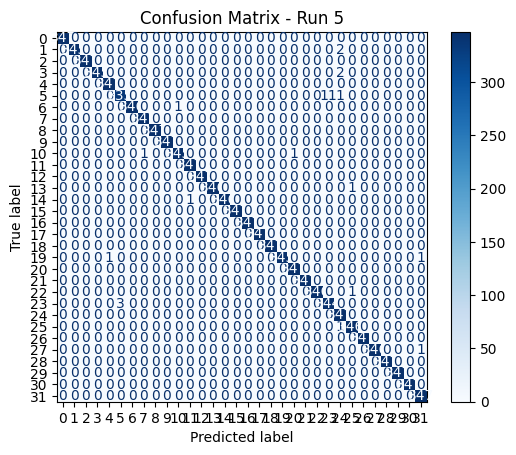

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9973 | ROC AUC: 1.0000
F1 Weighted: 0.9974 | Precision Weighted: 0.9974 | Recall Weighted: 0.9974
Training Time: 669.20s | Memory Used: 131.67 MB

--- Run 6 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 41s - 59ms/step - accuracy: 0.7106 - loss: 1.0059 - val_accuracy: 0.9776 - val_loss: 0.1084
Epoch 2/20
694/694 - 33s - 47ms/step - accuracy: 0.9708 - loss: 0.1033 - val_accuracy: 0.9923 - val_loss: 0.0380
Epoch 3/20
694/694 - 41s - 58ms/step - accuracy: 0.9853 - loss: 0.0520 - val_accuracy: 0.9900 - val_loss: 0.0370
Epoch 4/20
694/694 - 41s - 59ms/step - accuracy: 0.9885 - loss: 0.0391 - val_accuracy: 0.9905 - val_loss: 0.0353
Epoch 5/20
694/694 - 42s - 60ms/step - accuracy: 0.9896 - loss: 0.0356 - val_accuracy: 0.9902 - val_loss: 0.0346
Epoch 6/20
694/694 - 40s - 58ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9942 - val_loss: 0.0236
Epoch 7/20
694/694 - 42s - 60ms/step - accuracy: 0.9899 - loss: 0.0343 - val_accuracy: 0.9899 - val_loss: 0.0348
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9815 - val_loss: 0.0745
Epoch 9/20
694/694 - 40s - 58ms/step - accuracy: 0.9926 - loss: 0.0241 - val_accuracy: 0.9955 - 

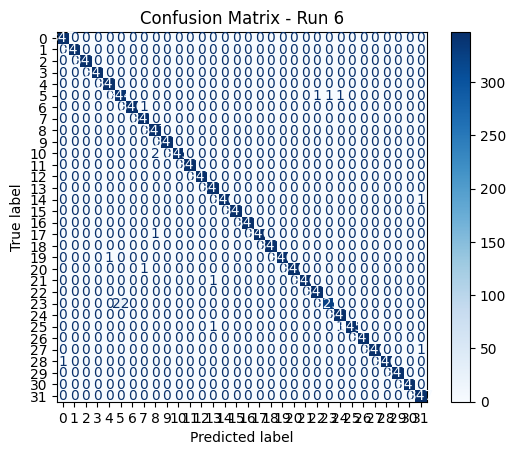

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9966 | ROC AUC: 1.0000
F1 Weighted: 0.9967 | Precision Weighted: 0.9968 | Recall Weighted: 0.9967
Training Time: 783.15s | Memory Used: 142.51 MB

--- Run 7 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 43s - 61ms/step - accuracy: 0.7055 - loss: 1.0343 - val_accuracy: 0.9700 - val_loss: 0.1243
Epoch 2/20
694/694 - 31s - 44ms/step - accuracy: 0.9693 - loss: 0.1078 - val_accuracy: 0.9898 - val_loss: 0.0407
Epoch 3/20
694/694 - 26s - 38ms/step - accuracy: 0.9860 - loss: 0.0513 - val_accuracy: 0.9935 - val_loss: 0.0295
Epoch 4/20
694/694 - 41s - 59ms/step - accuracy: 0.9878 - loss: 0.0427 - val_accuracy: 0.9941 - val_loss: 0.0244
Epoch 5/20
694/694 - 28s - 40ms/step - accuracy: 0.9878 - loss: 0.0403 - val_accuracy: 0.9910 - val_loss: 0.0297
Epoch 6/20
694/694 - 40s - 57ms/step - accuracy: 0.9879 - loss: 0.0407 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 7/20
694/694 - 28s - 40ms/step - accuracy: 0.9925 - loss: 0.0257 - val_accuracy: 0.9946 - val_loss: 0.0221
Epoch 8/20
694/694 - 40s - 57ms/step - accuracy: 0.9899 - loss: 0.0326 - val_accuracy: 0.9924 - val_loss: 0.0318
Epoch 9/20
694/694 - 41s - 59ms/step - accuracy: 0.9946 - loss: 0.0190 - val_accuracy: 0.9942 - 

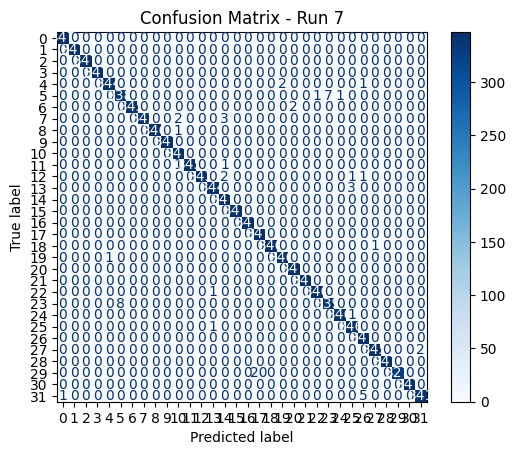

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9935 | ROC AUC: 0.9999
F1 Weighted: 0.9937 | Precision Weighted: 0.9938 | Recall Weighted: 0.9937
Training Time: 669.66s | Memory Used: 232.27 MB

--- Run 8 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 42s - 61ms/step - accuracy: 0.6901 - loss: 1.0747 - val_accuracy: 0.9389 - val_loss: 0.2185
Epoch 2/20
694/694 - 27s - 39ms/step - accuracy: 0.9681 - loss: 0.1091 - val_accuracy: 0.9845 - val_loss: 0.0548
Epoch 3/20
694/694 - 41s - 58ms/step - accuracy: 0.9861 - loss: 0.0515 - val_accuracy: 0.9924 - val_loss: 0.0281
Epoch 4/20
694/694 - 28s - 40ms/step - accuracy: 0.9874 - loss: 0.0444 - val_accuracy: 0.9920 - val_loss: 0.0305
Epoch 5/20
694/694 - 40s - 57ms/step - accuracy: 0.9875 - loss: 0.0412 - val_accuracy: 0.9917 - val_loss: 0.0342
Epoch 6/20
694/694 - 41s - 60ms/step - accuracy: 0.9892 - loss: 0.0367 - val_accuracy: 0.9917 - val_loss: 0.0286
Epoch 7/20
694/694 - 41s - 60ms/step - accuracy: 0.9912 - loss: 0.0300 - val_accuracy: 0.9950 - val_loss: 0.0201
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9913 - loss: 0.0304 - val_accuracy: 0.9903 - val_loss: 0.0380
Epoch 9/20
694/694 - 40s - 58ms/step - accuracy: 0.9923 - loss: 0.0258 - val_accuracy: 0.9959 - 

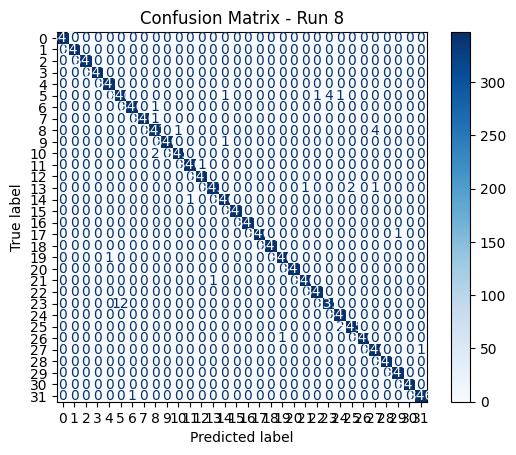

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
MCC: 0.9960 | ROC AUC: 0.9999
F1 Weighted: 0.9961 | Precision Weighted: 0.9961 | Recall Weighted: 0.9961
Training Time: 707.48s | Memory Used: 96.44 MB

--- Run 9 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 43s - 63ms/step - accuracy: 0.7002 - loss: 1.0479 - val_accuracy: 0.9730 - val_loss: 0.1258
Epoch 2/20
694/694 - 27s - 38ms/step - accuracy: 0.9693 - loss: 0.1060 - val_accuracy: 0.9930 - val_loss: 0.0312
Epoch 3/20
694/694 - 41s - 59ms/step - accuracy: 0.9853 - loss: 0.0521 - val_accuracy: 0.9901 - val_loss: 0.0371
Epoch 4/20
694/694 - 41s - 60ms/step - accuracy: 0.9875 - loss: 0.0434 - val_accuracy: 0.9911 - val_loss: 0.0345
Epoch 5/20
694/694 - 41s - 59ms/step - accuracy: 0.9892 - loss: 0.0355 - val_accuracy: 0.9846 - val_loss: 0.0478
Epoch 6/20
694/694 - 42s - 60ms/step - accuracy: 0.9902 - loss: 0.0337 - val_accuracy: 0.9891 - val_loss: 0.0405
Epoch 7/20
694/694 - 40s - 58ms/step - accuracy: 0.9910 - loss: 0.0306 - val_accuracy: 0.9842 - val_loss: 0.0490
Epoch 8/20
694/694 - 41s - 59ms/step - accuracy: 0.9904 - loss: 0.0318 - val_accuracy: 0.9950 - val_loss: 0.0216
Epoch 9/20
694/694 - 42s - 60ms/step - accuracy: 0.9935 - loss: 0.0217 - val_accuracy: 0.9888 - 

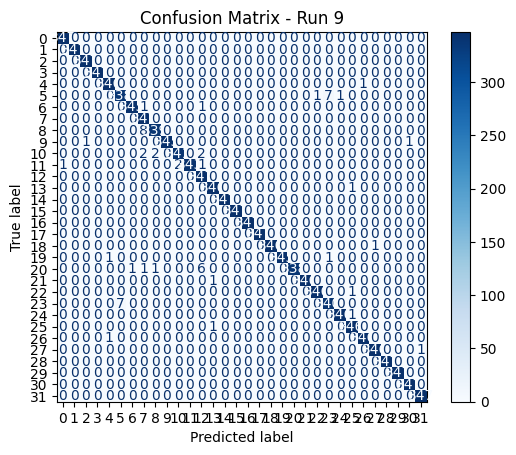

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9946 | ROC AUC: 0.9999
F1 Weighted: 0.9948 | Precision Weighted: 0.9948 | Recall Weighted: 0.9948
Training Time: 723.24s | Memory Used: 142.95 MB

--- Run 10 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
694/694 - 42s - 61ms/step - accuracy: 0.7105 - loss: 1.0129 - val_accuracy: 0.9758 - val_loss: 0.1068
Epoch 2/20
694/694 - 27s - 39ms/step - accuracy: 0.9718 - loss: 0.0995 - val_accuracy: 0.9914 - val_loss: 0.0341
Epoch 3/20
694/694 - 26s - 38ms/step - accuracy: 0.9871 - loss: 0.0479 - val_accuracy: 0.9918 - val_loss: 0.0320
Epoch 4/20
694/694 - 41s - 59ms/step - accuracy: 0.9870 - loss: 0.0446 - val_accuracy: 0.9912 - val_loss: 0.0355
Epoch 5/20
694/694 - 27s - 39ms/step - accuracy: 0.9888 - loss: 0.0385 - val_accuracy: 0.9924 - val_loss: 0.0263
Epoch 6/20
694/694 - 40s - 58ms/step - accuracy: 0.9897 - loss: 0.0350 - val_accuracy: 0.9939 - val_loss: 0.0206
Epoch 7/20
694/694 - 27s - 38ms/step - accuracy: 0.9909 - loss: 0.0327 - val_accuracy: 0.9928 - val_loss: 0.0296
Epoch 8/20
694/694 - 26s - 38ms/step - accuracy: 0.9942 - loss: 0.0217 - val_accuracy: 0.9927 - val_loss: 0.0279
Epoch 9/20
694/694 - 26s - 38ms/step - accuracy: 0.9915 - loss: 0.0282 - val_accuracy: 0.9962 - 

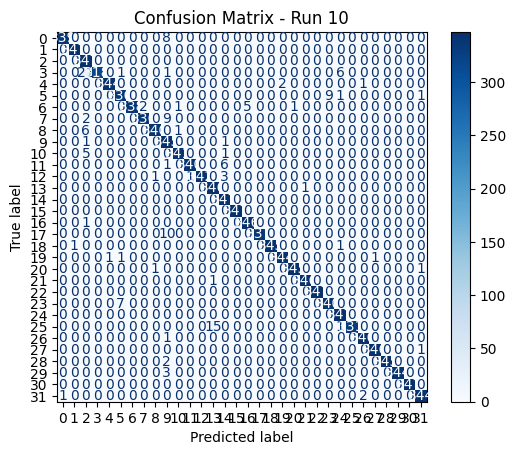

347/347 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MCC: 0.9860 | ROC AUC: 0.9999
F1 Weighted: 0.9865 | Precision Weighted: 0.9871 | Recall Weighted: 0.9864
Training Time: 707.62s | Memory Used: 216.52 MB
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.996128  0.013219  0.996004  0.999986     0.996123   
1    2      0.997118  0.012121  0.997026  0.999936     0.997115   
2    3      0.996037  0.019859  0.995912  0.999968     0.996037   
3    4      0.991895  0.039833  0.991640  0.999893     0.991908   
4    5      0.997388  0.012697  0.997305  0.999958     0.997388   
5    6      0.996668  0.012199  0.996564  0.999959     0.996666   
6    7      0.993696  0.026438  0.993497  0.999931     0.993694   
7    8      0.996128  0.018536  0.996003  0.999925     0.996126   
8    9      0.994777  0.021927  0.994610  0.999917     0.994779   
9   10      0.986401  0.044160  0.985981  0.999932     0.986478   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Use

In [4]:
import time
import psutil
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

num_runs = 10
results = []

for run in range(1, num_runs+1):
    print(f"\n--- Run {run} ---")

    # --- Start measuring memory & time ---
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss / (1024 ** 2)  # MB

    model = build_cnn()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=20,
        batch_size=64,
        verbose=2
    )

    # --- End measuring memory & time ---
    end_time = time.time()
    end_mem = psutil.Process().memory_info().rss / (1024 ** 2)

    train_time = end_time - start_time
    train_memory = end_mem - start_mem

    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    print(f"Validation Accuracy: {val_acc:.4f} | Validation Loss: {val_loss:.4f}")

    # --- Predictions ---
    y_pred = np.argmax(model.predict(x_val), axis=1)

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Run {run}")
    plt.show()

    # --- MCC ---
    mcc = matthews_corrcoef(y_val, y_pred)

    # --- ROC AUC ---
    y_val_bin = label_binarize(y_val, classes=np.arange(num_classes))
    y_pred_prob = model.predict(x_val)
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob, average='macro', multi_class='ovr')

    # --- Weighted metrics ---
    f1_w = f1_score(y_val, y_pred, average='weighted')
    precision_w = precision_score(y_val, y_pred, average='weighted')
    recall_w = recall_score(y_val, y_pred, average='weighted')

    print(f"MCC: {mcc:.4f} | ROC AUC: {roc_auc:.4f}")
    print(f"F1 Weighted: {f1_w:.4f} | Precision Weighted: {precision_w:.4f} | Recall Weighted: {recall_w:.4f}")
    print(f"Training Time: {train_time:.2f}s | Memory Used: {train_memory:.2f} MB")

    # --- Store all metrics ---
    results.append({
        'Run': run,
        'Val_Accuracy': val_acc,
        'Val_Loss': val_loss,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'F1_Weighted': f1_w,
        'Precision_Weighted': precision_w,
        'Recall_Weighted': recall_w,
        'Training_Time(s)': train_time,
        'Memory_Used(MB)': train_memory
    })

# --- Convert to DataFrame & save ---
df_metrics = pd.DataFrame(results)
print(df_metrics)
df_metrics.to_excel("all_metrics_10runs_with_time_memory.xlsx", index=False)
print("Saved all metrics with time & memory for 10 runs to all_metrics_10runs_with_time_memory.xlsx")


In [5]:
df_results = pd.DataFrame(results)
df_results.to_excel('/content/drive/MyDrive/alphabet/CNN_runs_analysis_Over.xlsx', index=False)
print("✅ Results saved to CNN_runs_analysis.xlsx")
print(df_results)


✅ Results saved to CNN_runs_analysis.xlsx
   Run  Val_Accuracy  Val_Loss       MCC   ROC_AUC  F1_Weighted  \
0    1      0.996128  0.013219  0.996004  0.999986     0.996123   
1    2      0.997118  0.012121  0.997026  0.999936     0.997115   
2    3      0.996037  0.019859  0.995912  0.999968     0.996037   
3    4      0.991895  0.039833  0.991640  0.999893     0.991908   
4    5      0.997388  0.012697  0.997305  0.999958     0.997388   
5    6      0.996668  0.012199  0.996564  0.999959     0.996666   
6    7      0.993696  0.026438  0.993497  0.999931     0.993694   
7    8      0.996128  0.018536  0.996003  0.999925     0.996126   
8    9      0.994777  0.021927  0.994610  0.999917     0.994779   
9   10      0.986401  0.044160  0.985981  0.999932     0.986478   

   Precision_Weighted  Recall_Weighted  Training_Time(s)  Memory_Used(MB)  
0            0.996157         0.996128        783.916794      1088.898438  
1            0.997149         0.997118        779.279436       203.1


📊 Average Results across all runs:
Average Accuracy : 0.9946
Average Loss     : 0.0221
Average MCC      : 0.9945
Average ROC AUC  : 0.9999

✅ Results saved to /content/drive/MyDrive/alphabet/CNN_runs_results.xlsx


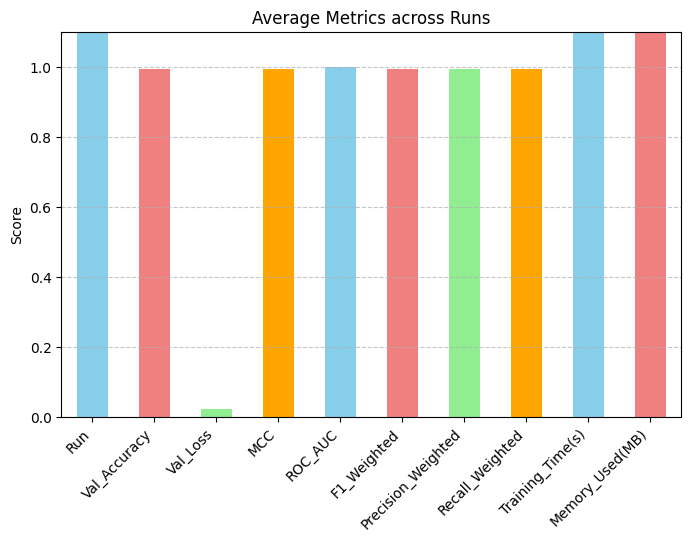

In [6]:
import matplotlib.pyplot as plt

# --- تحويل النتائج ل DataFrame ---
results_df = pd.DataFrame(results)

# --- حساب المتوسط لكل مقياس ---
avg_results = results_df.mean(numeric_only=True)

print("\n📊 Average Results across all runs:")
print(f"Average Accuracy : {avg_results['Val_Accuracy']:.4f}")
print(f"Average Loss     : {avg_results['Val_Loss']:.4f}")
print(f"Average MCC      : {avg_results['MCC']:.4f}")
print(f"Average ROC AUC  : {avg_results['ROC_AUC']:.4f}")

# --- حفظ النتائج في Excel ---
save_path = "/content/drive/MyDrive/alphabet/CNN_runs_results.xlsx"
with pd.ExcelWriter(save_path) as writer:
    results_df.to_excel(writer, sheet_name="All Runs", index=False)
    avg_results.to_frame(name="Average").to_excel(writer, sheet_name="Average")

print(f"\n✅ Results saved to {save_path}")

# --- رسم المتوسطات ---
plt.figure(figsize=(8,5))
avg_results.plot(kind='bar', color=['skyblue','lightcoral','lightgreen','orange'])
plt.title("Average Metrics across Runs")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)  # معظم المقاييس بتبقى بين 0 و 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d634b78ce1871b8dfa6f2fbaa6b8603deb45fb0ac4d42d78096215884f9a67a8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
📐 Input Shape: 64x64x1


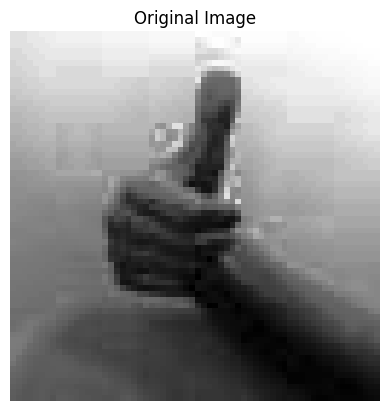

Predicted class: aleff (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

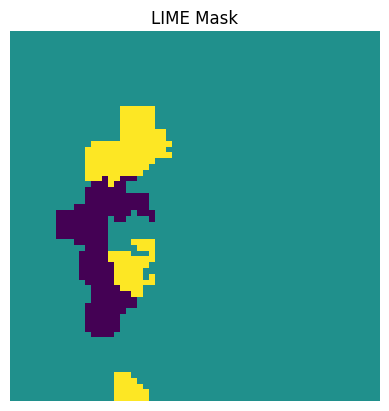

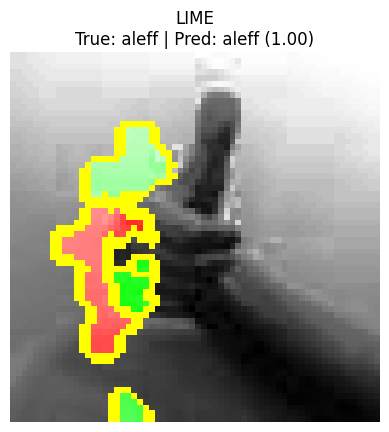

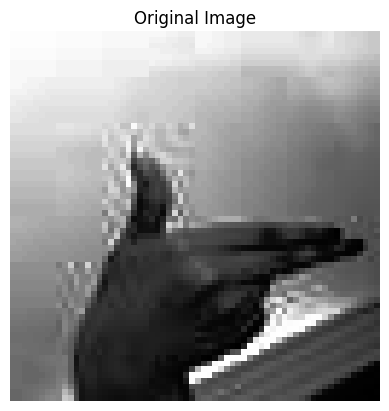

Predicted class: ghain (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

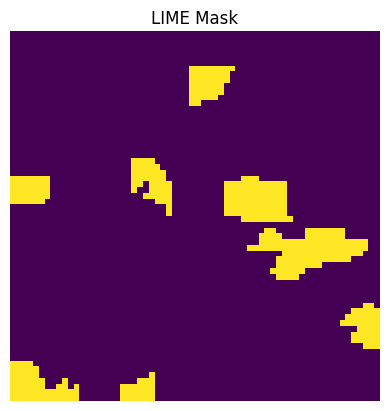

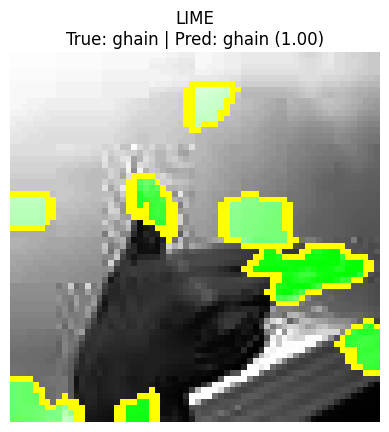

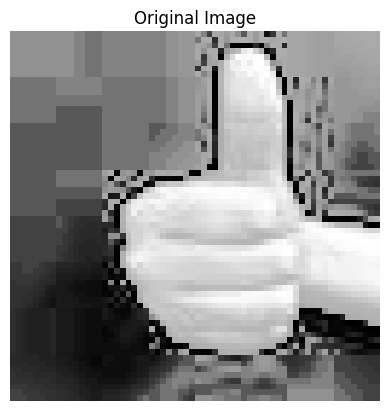

Predicted class: aleff (1.00)


  0%|          | 0/1000 [00:00<?, ?it/s]

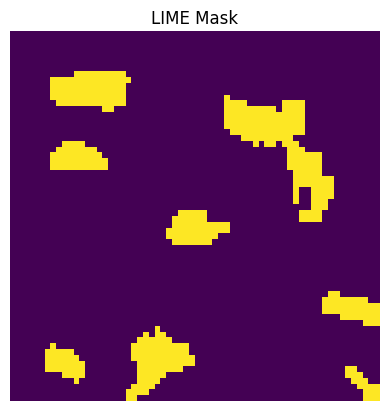

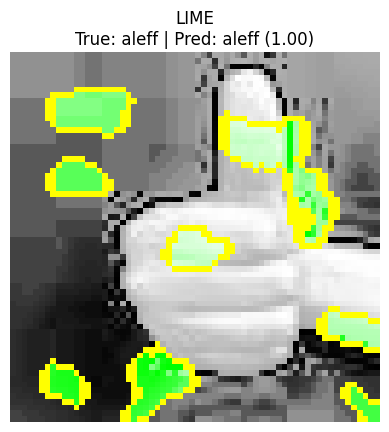

In [7]:
!pip install lime
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
from skimage.transform import resize

# تحميل أسماء الكلاسات
class_names = np.load('/content/drive/MyDrive/alphabet/label_encoder_classes.npy', allow_pickle=True)

# استخراج شكل مدخلات الموديل
H, W, C = model.input_shape[1:]
print(f"📐 Input Shape: {H}x{W}x{C}")

# دالة تجهيز الصور زي التدريب
def preprocess_batch(images):
    out = []
    for im in images:
        im = np.asarray(im)
        if im.ndim == 2:  # صورة رمادية
            im = np.repeat(im[..., np.newaxis], 3, axis=-1)
            im = np.squeeze(im)
        elif im.shape[-1] == 1 and C == 3:
            im = np.repeat(im, 3, axis=-1)
            im = np.squeeze(im)
        # تغيير الحجم لتوافق مدخلات الموديل
        im = resize(im, (H, W, C), preserve_range=True, anti_aliasing=True).astype('float32')
        if im.max() > 1.0:
            im = im / 255.0
        out.append(im)
    return np.asarray(out, dtype='float32')

# دالة التنبؤ لـ LIME
def predict_fn(images):
    Xb = preprocess_batch(images)
    return model.predict(Xb, verbose=0)

# إنشاء مفسر LIME
explainer = lime_image.LimeImageExplainer()

# اختيار صور عشوائية للتفسير
indices = np.random.choice(len(x_val), size=3, replace=False)

for idx in indices:
    image = x_val[idx]

    # تجهيز نسخة RGB للعرض
    if image.ndim == 2 or image.shape[-1] == 1:
        image_rgb = np.repeat(image[..., np.newaxis], 3, axis=-1)
        image_rgb = np.squeeze(image_rgb)
    else:
        image_rgb = image
    image_rgb = image_rgb[..., :3]

    # --- عرض الصورة الأصلية ---
    plt.figure()
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # --- تنبؤ الموديل ---
    pred_probs = model.predict(preprocess_batch([image]), verbose=0)[0]
    pred_label = int(np.argmax(pred_probs))
    print(f"Predicted class: {class_names[pred_label]} ({pred_probs[pred_label]:.2f})")

    # --- تفسير LIME ---
    explanation = explainer.explain_instance(
        image_rgb.astype('double'),
        predict_fn,
        labels=[pred_label],
        hide_color=0,
        num_samples=1000,
        segmentation_fn=slic
    )

    # --- استخراج الـ mask ---
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    # --- عرض الـ mask ---
    plt.figure()
    plt.imshow(mask)
    plt.title("LIME Mask")
    plt.axis('off')
    plt.show()

    # --- عرض الصورة مع الحدود ---
    true_class_name = class_names[int(y_val[idx])]
    predicted_class_name = class_names[pred_label]
    plt.figure()
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME\nTrue: {true_class_name} | Pred: {predicted_class_name} ({pred_probs[pred_label]:.2f})")
    plt.axis('off')
    plt.show()


In [8]:
import numpy as np

# حفظ الموديل بصيغة Keras الجديدة
model.save('/content/drive/MyDrive/alphabet/my_modelcnn_over.keras')

# حفظ بيانات validation (لو محتاجة تكمل عليها)
np.save('/content/drive/MyDrive/alphabet/x_val.npy', x_val)
np.save('/content/drive/MyDrive/alphabet/y_val.npy', y_val)
